In [1]:
import os
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import scipy.stats as stats
import pandas as pd
from causalgraphicalmodels import CausalGraphicalModel

__Probabilistic Programming. Wasowski. Pardo. IT University of Copenhagen__

This file contains the list of exercises for the week, as well as any related code.

# 9E1

Which of the following is a requirement of the simple Metropolis algorithm?
(1) The parameters must be discrete.
(2) The likelihood function must be Gaussian.
(3) The proposal distribution must be symmetric.

Answer: (3) The proposal distribution must be symmetric.
because the acceptance probability is defined as the ratio of the likelihoods of the proposed and current states, and the proposal distribution cancels out.

# 9E2

Gibbs sampling is more efficient than the Metropolis algorithm. How does it achieve this extra
efficiency? Are there any limitations to the Gibbs sampling strategy?

Answer: Gibbs sampling is more efficient than the Metropolis algorithm because it can sample from the posterior distribution of each parameter in turn, rather than sampling from the joint posterior distribution of all parameters at once. This is more efficient because it can take advantage of the conditional independence of the parameters. However, Gibbs sampling can be limited by the need to derive the conditional distributions of the parameters, which can be difficult or impossible in some cases.

# 9E3

Which sort of parameters can Hamiltonian Monte Carlo not handle? Can you explain why?

Answer: Hamiltonian Monte Carlo cannot handle discrete parameters because the Hamiltonian dynamics are continuous and differentiable, and the leapfrog integrator requires the gradient of the log posterior with respect to the parameters. Discrete parameters do not have a gradient, so the leapfrog integrator cannot be applied to them.

# 9E4

Explain the difference between the effective number of samples, n_eff as calculated by Stan,
and the actual number of samples.

Answer: The effective number of samples, n_eff, as calculated by Stan, is a measure of the effective number of independent samples in the Markov chain. It takes into account the autocorrelation between samples, so that if the samples are highly correlated, the effective number of samples will be lower than the actual number of samples. This is important because the effective number of samples determines the effective sample size of the posterior distribution, which affects the accuracy of the estimates of the posterior mean and variance.

# 9E5

Which value should Rhat approach, when a chain is sampling the posterior distribution correctly?

Answer: We want it to be close to 1, because it is a measure of the convergence of the chains. If Rhat is close to 1, it indicates that the chains have converged to the same stationary distribution, and that the samples are representative of the posterior distribution. If Rhat is far from 1, it indicates that the chains have not converged, and that the samples are not representative of the posterior distribution.

# 9E6

Sketch a good trace plot for a Markov chain, one that is effectively sampling from the posterior
distribution. What is good about its shape? Then sketch a trace plot for a malfunctioning Markov
chain. What about its shape indicates malfunction?

Answer: A good trace plot for a Markov chain that is effectively sampling from the posterior distribution will have a random, oscillating pattern with no clear trend or pattern. This indicates that the chain is exploring the parameter space effectively and is converging to the posterior distribution. A malfunctioning Markov chain will have a clear trend or pattern, such as a linear increase or decrease, which indicates that the chain is not exploring the parameter space effectively and is not converging to the posterior distribution.

From the lecture we had 3 plots with sd=0.02, 0.2, 2.0. The first one has too small of a step size limiting its ability to explore the parameter space. The second one has a good step size and the third one has too large of a step size.
We can see that the step size is too large in the third plot because it sometimes stops on surtain values and then makes a big jump to another value. This is not good because it is not exploring the parameter space effectively.

# Exercises

The exercises for this week are: all exercises from Chapter 9, McElreath, with exceptions and remarks noted below.

* __9E1, 9E2, 9E3, 9E4, 9E5, 9E6__ discussion questions
* __9E7__ skip the exercise. Instead modify the code in the lecture to display a __rank plot__ instead of a trace plot, and interpret it. Search here for "rank plot" to see how to switch to a rank plot: https://python.arviz.org/en/v0.17.0/api/generated/arviz.plot_trace.html . The rank plots made with arviz look a bit different than in the book (they are not overlayed), but the semantics seem to be the same. In a nutshell, rank plots show a histogram of the ranked posterior samples. If all chains target teh same posterior ranks should appear uniform.

* __9M1__ The exercise uses the terrain ruggedness model for the chapter.  I report it here after https://github.com/pymc-devs/resources/tree/main/Rethinking_2 for your convenience.

In [2]:
d = pd.read_csv("Data/rugged.csv", delimiter=";")

d["log_gdp"] = np.log(d["rgdppc_2000"])
dd = d.dropna(subset=["log_gdp"]).copy()

dd["log_gdp_std"] = dd["log_gdp"] / dd["log_gdp"].mean()
dd["rugged_std"] = dd["rugged"] / dd["rugged"].max()

In [3]:
cid = pd.Categorical(dd["cont_africa"])

with pm.Model() as m_8_3:
    a = pm.Normal("a", 1, 0.2, shape=cid.categories.size)
    b = pm.Normal("b", 0, 0.3, shape=cid.categories.size)

    mu = a[cid.codes] + b[cid.codes] * (dd["rugged_std"] - 0.215)
    sigma = pm.Exponential("sigma", 1)

    log_gdp_std = pm.Normal("log_gdp_std", mu, sigma, observed = dd["log_gdp_std"])

    m_8_3_trace = pm.sample()

az.summary(m_8_3_trace, kind="all", round_to=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 36 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a[0],1.05,0.01,1.03,1.07,0.0,0.0,5499.28,3227.76,1.0
a[1],0.88,0.02,0.85,0.91,0.0,0.0,6146.08,3212.86,1.0
b[0],-0.14,0.06,-0.25,-0.04,0.0,0.0,7336.56,3265.50,1.0
b[1],0.13,0.08,-0.01,0.27,0.0,0.0,5363.93,3319.89,1.0
sigma,0.11,0.01,0.10,0.12,0.0,0.0,6604.31,3842.41,1.0


In [4]:
# unifrom sigma

with pm.Model() as m_8_4:
    a = pm.Normal("a", 1, 0.2, shape=cid.categories.size)
    b = pm.Normal("b", 0, 0.3, shape=cid.categories.size)

    mu = a[cid.codes] + b[cid.codes] * (dd["rugged_std"] - 0.215)
    sigma = pm.Uniform("sigma", 0, 1)

    log_gdp_std = pm.Normal("log_gdp_std", mu, sigma, observed = dd["log_gdp_std"])

    m_8_4_trace = pm.sample()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 37 seconds.


In [5]:
az.summary(m_8_4_trace, kind="all", round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a[0],1.05,0.01,1.03,1.07,0.0,0.0,5226.48,3270.48,1.0
a[1],0.88,0.02,0.86,0.91,0.0,0.0,4657.55,2972.89,1.0
b[0],-0.14,0.06,-0.25,-0.04,0.0,0.0,5541.18,3603.46,1.0
b[1],0.13,0.08,-0.01,0.28,0.0,0.0,5747.64,3121.80,1.0
sigma,0.11,0.01,0.10,0.12,0.0,0.0,6289.15,3393.83,1.0


A sigma The probablity in exponential(1) and uniform(0,1) has about the same probability in the range 0..1, so changing the sigma 

* __9M2__: use the code above
* __9M3__: we have done this a bit in the lecture. Recall that for HMC (and consequently NUTS) warm up period is defined in the `tune` parameter for the `sample` method.
* __9H1__: The model code in PyMC, courtesy of https://github.com/pymc-devs/resources/tree/main/Rethinking_2

In [7]:
# 9M2
"""
Modify the terrain ruggedness model again. This time, change the prior for b[cid] to dexp(0.3).
What does this do to the posterior distribution? Can you explain it?
"""

with pm.Model() as m_9M2:
    a = pm.Normal("a", 1, 0.2, shape=cid.categories.size)
    b = pm.Exponential("b", 0.3, shape=cid.categories.size)

    mu = a[cid.codes] + b[cid.codes] * (dd["rugged_std"] - 0.215)
    sigma = pm.Exponential("sigma", 1)

    log_gdp_std = pm.Normal("log_gdp_std", mu, sigma, observed = dd["log_gdp_std"])

    m_9M2_trace = pm.sample()

az.summary(m_9M2_trace, kind="all", round_to=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 38 seconds.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a[0],1.05,0.01,1.03,1.07,0.0,0.0,3171.82,2367.81,1.0
a[1],0.88,0.02,0.85,0.92,0.0,0.0,2661.82,2289.55,1.0
b[0],0.02,0.02,0.00,0.05,0.0,0.0,2270.58,1409.12,1.0
b[1],0.15,0.07,0.01,0.27,0.0,0.0,1613.28,994.67,1.0
sigma,0.11,0.01,0.10,0.13,0.0,0.0,2801.71,2298.39,1.0


We can see on b that making it exponential makes the model lose information and lands it with a hdi that is about 0. The exponential distribution is not a good fit for this model.

In [ ]:
# 9M3
"""
Re-estimate one of the Stan models from the chapter, but at different numbers of warmup iterations. Be sure to use the same number of sampling iterations in each case. Compare the n_eff
values. How much warmup is enough?
"""

with pm.Model() as hmc_fixed:
    σ = pm.Exponential('σ', 1)
    α = pm.Normal('α',0,10)
    y = pm.Normal('y',mu=α, sigma=σ, observed=[-1,1])
    trace_10 = pm.sample(1000, tune=10, chains=4, target_accept=0.95)
    
    trace_100 = pm.sample(1000, tune=100, chains=4, target_accept=0.95)
    
    trace_1000 = pm.sample(1000, tune=1000, chains=4, target_accept=0.95)

In [9]:
az.summary(trace_10, kind="all", round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α,-0.07,1.17,-2.51,2.01,0.04,0.03,877.22,775.83,1.00
σ,1.56,0.85,0.46,3.07,0.03,0.02,1313.15,1592.69,1.01


In [10]:
az.summary(trace_100, kind="all", round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α,-0.03,1.29,-2.61,2.37,0.04,0.04,924.48,863.50,1.01
σ,1.59,0.89,0.46,3.21,0.02,0.02,1536.90,1724.15,1.01


In [11]:
az.summary(trace_1000, kind="all", round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α,-0.04,1.15,-2.16,2.17,0.04,0.03,1161.11,967.14,1.0
σ,1.55,0.81,0.46,3.03,0.03,0.02,918.92,1578.34,1.0


In [12]:
with pm.Model() as H1:
    a = pm.Normal("a", 0, 0.1)
    b = pm.Cauchy("b", 0, 1)
    y = 1
    prior_sample = pm.sample_prior_predictive(samples=1000)
    H1_post_sample = pm.sample(draws=1000, chains=1)

Sampling: [a, b]
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [a, b]


Output()

Sampling 1 chain for 1_000 tune and 1_000 draw iterations (1_000 + 1_000 draws total) took 3 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


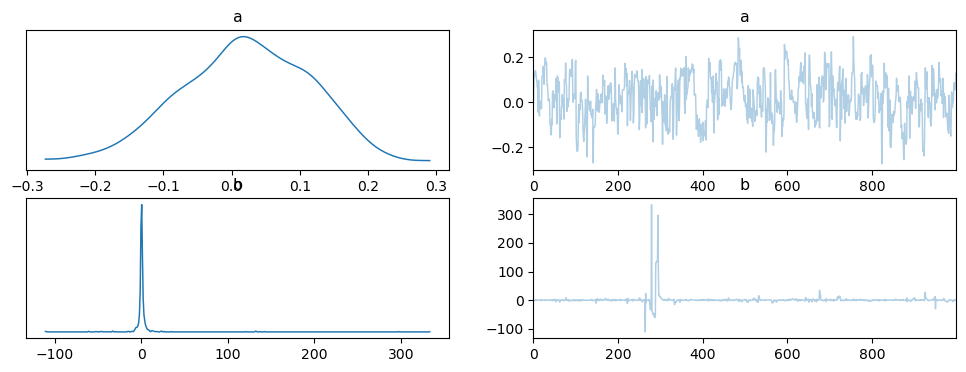

In [14]:
az.plot_trace(H1_post_sample)
plt.show()

In [13]:
az.summary(H1_post_sample, kind="all", round_to=2)

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.02,0.10,-0.16,0.19,0.01,0.01,136.11,249.94,NaN
b,1.06,18.85,-7.82,6.69,1.07,0.78,346.90,184.22,NaN


* __9H2__: The models are to be found in multiple-lecture.ipynb; search for `m_5_1` and `m_5_3` (just compare these two models, skip model number 2).  We already have done the exercise in the lecture. Can you see why?

* __9H3__: The model is in the confounds-lecture.ipynb; search for `m_6_1`. To add a constraint to a normal distribution in PyMC add a model entry: `BoundedNormal = pm.Bound(pm.Normal, lower=0.0)` and then you can use `BoundedNormal` like normal (the constructor takes the same parameters). 

* __9H4__: Recall that `arviz.compare` is the function that can compute information criteria for a sample

* __9H5__: We have already done something similar in the lecture, but try other function population functions and observe whether you get the expected estimation of the posterior.

* Exercises __9H6__ and __9H7__ are more classic computer science exercises (implementing algorithms). They all require translating a piece of code in the chapter to Python and then making some modifications to it.  I believe that translating this manually is valuable because you get involved with the algorithm better but if you want to save time, this notebook should have the code: https://github.com/pymc-devs/resources/blob/main/Rethinking_2/Chp_09.ipynb. 